In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import datetime as dt

In [85]:
claim=pd.read_csv(r"C:\Users\user\OneDrive\Desktop\python project\Case Study 3 - Insurance Claims Case Study\claims.csv")
claim.head(4)

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No


In [86]:
claim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1100 non-null   int64  
 1   customer_id          1100 non-null   int64  
 2   incident_cause       1100 non-null   object 
 3   claim_date           1100 non-null   object 
 4   claim_area           1100 non-null   object 
 5   police_report        1100 non-null   object 
 6   claim_type           1100 non-null   object 
 7   claim_amount         1035 non-null   object 
 8   total_policy_claims  1090 non-null   float64
 9   fraudulent           1100 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 86.1+ KB


In [87]:
cust=pd.read_csv(r"C:\Users\user\OneDrive\Desktop\python project\Case Study 3 - Insurance Claims Case Study\cust_demographics.csv")
cust.head(4)

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver


In [88]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CUST_ID      1085 non-null   int64 
 1   gender       1085 non-null   object
 2   DateOfBirth  1085 non-null   object
 3   State        1085 non-null   object
 4   Contact      1085 non-null   object
 5   Segment      1085 non-null   object
dtypes: int64(1), object(5)
memory usage: 51.0+ KB


#### 1. Import claims_data.csv and cust_data.csv which is provided to you and combine the two datasets appropriately to create a 360-degree view of the data. Use the same for the subsequent questions.

In [109]:
data=pd.merge(left=claim,right=cust,how='outer',left_on='customer_id',right_on='CUST_ID')
data=data.reset_index()
data.head(5)

,index,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,0,69348631.0,154557.0,Driver error,04/10/2018,Auto,No,Injury only,NaN,1.0,Yes,154557.0,Female,23-May-78,DE,962-879-1238,Platinum
1,1,40953049.0,263204.0,Other causes,04/04/2018,Auto,No,Material and injury,$39192,1.0,Yes,263204.0,Male,20-Dec-72,TX,173-892-6314,Silver
2,2,45780237.0,287476.0,Natural causes,10/17/2017,Auto,Unknown,Material only,$1621.5,2.0,Yes,287476.0,Male,28-Jul-88,FL,364-598-1549,Silver
3,3,89833962.0,441097.0,Other causes,03/21/2018,Auto,Yes,Material and injury,$37040,1.0,No,441097.0,Male,19-Aug-71,CA,187-348-8375,Gold
4,4,35782742.0,524545.0,Other driver error,07/27/2018,Auto,No,Injury only,$35250,3.0,No,524545.0,Female,10-Aug-80,NC,798-862-5398,Gold


In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1107 non-null   int64  
 1   claim_id             1100 non-null   float64
 2   customer_id          1100 non-null   float64
 3   incident_cause       1100 non-null   object 
 4   claim_date           1100 non-null   object 
 5   claim_area           1100 non-null   object 
 6   police_report        1100 non-null   object 
 7   claim_type           1100 non-null   object 
 8   claim_amount         1035 non-null   object 
 9   total_policy_claims  1090 non-null   float64
 10  fraudulent           1100 non-null   object 
 11  CUST_ID              1092 non-null   float64
 12  gender               1092 non-null   object 
 13  DateOfBirth          1092 non-null   object 
 14  State                1092 non-null   object 
 15  Contact              1092 non-null   o

In [111]:
data.drop(columns='CUST_ID',axis=1,inplace=True)

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1107 non-null   int64  
 1   claim_id             1100 non-null   float64
 2   customer_id          1100 non-null   float64
 3   incident_cause       1100 non-null   object 
 4   claim_date           1100 non-null   object 
 5   claim_area           1100 non-null   object 
 6   police_report        1100 non-null   object 
 7   claim_type           1100 non-null   object 
 8   claim_amount         1035 non-null   object 
 9   total_policy_claims  1090 non-null   float64
 10  fraudulent           1100 non-null   object 
 11  gender               1092 non-null   object 
 12  DateOfBirth          1092 non-null   object 
 13  State                1092 non-null   object 
 14  Contact              1092 non-null   object 
 15  Segment              1092 non-null   o

### 2. Perform a data audit for the datatypes and find out if there are any mismatch within the current datatypes of the columns and their business significance.

In [113]:
data['claim_date']=pd.to_datetime(data['claim_date'])
data['DateOfBirth']=pd.to_datetime(data['DateOfBirth'],errors='coerce')

C:\Users\user\AppData\Local\Temp\ipykernel_13020\1949921047.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['DateOfBirth']=pd.to_datetime(data['DateOfBirth'],errors='coerce')


In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   index                1107 non-null   int64         
 1   claim_id             1100 non-null   float64       
 2   customer_id          1100 non-null   float64       
 3   incident_cause       1100 non-null   object        
 4   claim_date           1100 non-null   datetime64[ns]
 5   claim_area           1100 non-null   object        
 6   police_report        1100 non-null   object        
 7   claim_type           1100 non-null   object        
 8   claim_amount         1035 non-null   object        
 9   total_policy_claims  1090 non-null   float64       
 10  fraudulent           1100 non-null   object        
 11  gender               1092 non-null   object        
 12  DateOfBirth          1092 non-null   datetime64[ns]
 13  State                1092 non-nul

#### 3. Convert the column claim_amount to numeric. Use the appropriate modules/attributes to remove the $ sign.

In [115]:
data['claim_amount']=data['claim_amount'].str.replace('$',' ',regex=False).astype('float')

In [126]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   index                1107 non-null   int64         
 1   claim_id             1100 non-null   float64       
 2   customer_id          1100 non-null   float64       
 3   incident_cause       1100 non-null   object        
 4   claim_date           1100 non-null   datetime64[ns]
 5   claim_area           1100 non-null   object        
 6   police_report        1100 non-null   object        
 7   claim_type           1100 non-null   object        
 8   claim_amount         1035 non-null   float64       
 9   total_policy_claims  1090 non-null   float64       
 10  fraudulent           1100 non-null   object        
 11  gender               1092 non-null   object        
 12  DateOfBirth          1092 non-null   datetime64[ns]
 13  State                1092 non-nul

### 4. Of all the injury claims, some of them have gone unreported with the police. Create an alert flag (1,0) for all such claims.

In [174]:
data['police_report_0_1']=np.where((data.police_report=='N0')&(data.claim_type=='Injury only'),'1','0')
data['police_report_0_1']=pd.to_numeric(data['police_report_0_1'])

C:\Users\user\AppData\Local\Temp\ipykernel_13020\3977920770.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['police_report_0_1']=np.where((data.police_report=='N0')&(data.claim_type=='Injury only'),'1','0')
C:\Users\user\AppData\Local\Temp\ipykernel_13020\3977920770.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['police_report_0_1']=pd.to_numeric(data['police_report_0_1'])


In [166]:
data['police_alert']=((data['claim_type'].str.contains('Injury only	',case=False))&(data['police_report'].isin(['No','Unknown']))).astype(int)

In [167]:
data.head(2)

,index,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,police_report_0_1,police_alert
0,0,69348631.0,154557.0,Driver error,2018-04-10,Auto,No,Injury only,NaN,1.0,Yes,Female,1978-05-23,DE,962-879-1238,Platinum,0,0
1,1,40953049.0,263204.0,Other causes,2018-04-04,Auto,No,Material and injury,39192.0,1.0,Yes,Male,2072-12-20,TX,173-892-6314,Silver,0,0


### 5 One customer can claim for insurance more than once and in each claim,multiple categories of claims can be involved. However, customer ID should remain unique. 

In [170]:
data=data.drop_duplicates(subset='customer_id',keep='last')

### 6. Check for missing values and impute the missing values with an appropriate value. (mean for continuous and mode for categorical)

In [175]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, 0 to 1106
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   index                1094 non-null   int64         
 1   claim_id             1093 non-null   float64       
 2   customer_id          1093 non-null   float64       
 3   incident_cause       1093 non-null   object        
 4   claim_date           1093 non-null   datetime64[ns]
 5   claim_area           1093 non-null   object        
 6   police_report        1093 non-null   object        
 7   claim_type           1093 non-null   object        
 8   claim_amount         1028 non-null   float64       
 9   total_policy_claims  1083 non-null   float64       
 10  fraudulent           1093 non-null   object        
 11  gender               1079 non-null   object        
 12  DateOfBirth          1079 non-null   datetime64[ns]
 13  State                1079 non-null   o

In [171]:
data.isna().sum()

index                   0
claim_id                1
customer_id             1
incident_cause          1
claim_date              1
claim_area              1
police_report           1
claim_type              1
claim_amount           66
total_policy_claims    11
fraudulent              1
gender                 15
DateOfBirth            15
State                  15
Contact                15
Segment                15
police_report_0_1       0
police_alert            0
dtype: int64

In [187]:
for col in data.select_dtypes(include='number'):
    data[col].fillna(data[col].mean(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13020\1238667650.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(),inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_13020\1238667650.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col].fillna(data[col].mean(),inplace=True)


In [181]:
for col in data.select_dtypes(include='object'):
    data[col].fillna(data[col].mode(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13020\3907780313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col].fillna(data[col].mode(),inplace=True)


In [222]:
data.isna().sum()

index                    0
claim_id                 0
customer_id              0
incident_cause           1
claim_date               1
claim_area               1
police_report            1
claim_type               1
claim_amount             0
total_policy_claims      0
fraudulent               1
gender                  15
DateOfBirth            442
State                   15
Contact                  1
Segment                 15
police_report_0_1        0
police_alert             0
Age                    443
dtype: int64

In [213]:
data.loc[data['DateOfBirth']>data['claim_date'],['DateOfBirth']]=pd.NaT

In [216]:
data['Age']=(data['claim_date']-data['DateOfBirth']).dt.days//365

C:\Users\user\AppData\Local\Temp\ipykernel_13020\2803560133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age']=(data['claim_date']-data['DateOfBirth']).dt.days//365


In [318]:
data['Age_group']=pd.cut(data['Age'],bins=([18,30,60,100]),labels=(['youth','adult','senior']),right=False)

In [315]:
data.head(5)

,index,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,police_report_0_1,police_alert,Age,Age_group
0,0,69348631.0,154557.0,Driver error,2018-04-10,Auto,No,Injury only,12475.266051,1.0,Yes,Female,1978-05-23,DE,962-879-1238,Platinum,0,0,39.0,adult
1,1,40953049.0,263204.0,Other causes,2018-04-04,Auto,No,Material and injury,39192.000000,1.0,Yes,Male,NaT,TX,173-892-6314,Silver,0,0,NaN,NaN
2,2,45780237.0,287476.0,Natural causes,2017-10-17,Auto,Unknown,Material only,1621.500000,2.0,Yes,Male,1988-07-28,FL,364-598-1549,Silver,0,0,29.0,youth
3,3,89833962.0,441097.0,Other causes,2018-03-21,Auto,Yes,Material and injury,37040.000000,1.0,No,Male,NaT,CA,187-348-8375,Gold,0,0,NaN,NaN
4,4,35782742.0,524545.0,Other driver error,2018-07-27,Auto,No,Injury only,35250.000000,3.0,No,Female,1980-08-10,NC,798-862-5398,Gold,0,0,37.0,adult


## 8. What is the average amount claimed by the customers from various segments

In [316]:
data.groupby('Segment')['claim_amount'].mean()

Segment
Gold        12844.831140
Platinum    12370.555376
Silver      12265.630304
Name: claim_amount, dtype: float64

### 9. What is the total claim amount based on incident cause for all the claims that have been done at least 20 days prior to 1st of October, 2018.

In [319]:
cutoff = pd.Timestamp('2018-10-01') - pd.Timedelta(days=20)

data[data['claim_date'] < cutoff] \
.groupby('incident_cause')['claim_amount'].sum()


incident_cause
Crime                 7.269583e+05
Driver error          3.344543e+06
Natural causes        1.315059e+06
Other causes          3.778019e+06
Other driver error    3.342800e+06
Name: claim_amount, dtype: float64

### 10. How many adults from TX, DE and AK claimed insurance for driver related issues and causes? 

In [321]:
data.columns

Index(['index', 'claim_id', 'customer_id', 'incident_cause', 'claim_date',
       'claim_area', 'police_report', 'claim_type', 'claim_amount',
       'total_policy_claims', 'fraudulent', 'gender', 'DateOfBirth', 'State',
       'Contact', 'Segment', 'police_report_0_1', 'police_alert', 'Age',
       'Age_group'],
      dtype='object')

In [333]:
data[(data.Age_group=='Adult')&(data.State.isin(['TX','DE','AK']))&(data.incident_cause=='Driver')].shape[0]

0

### 11. Pie Chart – Claim Amount by Gender & Segment

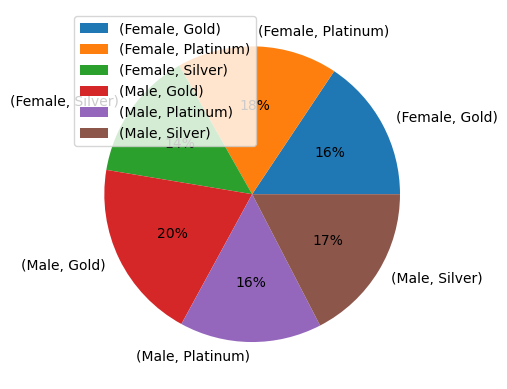

In [335]:
pie_data=data.groupby(['gender','Segment'])['claim_amount'].sum()
pie_data.plot(kind='pie',autopct='%2.f%%')
plt.ylabel(' ')
plt.legend()
plt.show()

### 12. Among males and females, which gender had claimed the most for any type of driver related issues? E.g. This metric can be compared using a bar chart

In [349]:
m_f_incident=data.loc[data['incident_cause'].isin(['Driver error',]),['claim_amount','gender','incident_cause']]
m_f_incident.head(4)

,claim_amount,gender,incident_cause
0,12475.266051,Female,Driver error
8,2490.000000,Male,Driver error
10,25010.000000,Female,Driver error
14,3208.500000,Male,Driver error


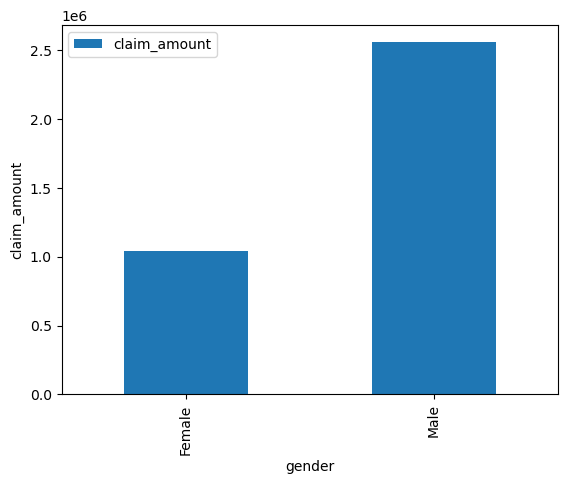

In [354]:
chart_m_f=pd.DataFrame(m_f_incident.groupby('gender')['claim_amount'].sum())
chart_m_f=chart_m_f.reset_index()
chart_m_f.plot(kind='bar',x='gender',y='claim_amount')
plt.ylabel('claim_amount')
plt.show()

In [347]:
data.loc[data['incident_cause'].isin(['Driver error',]),['claim_amount','gender','incident_cause']]

,claim_amount,gender,incident_cause
0,12475.266051,Female,Driver error
8,2490.000000,Male,Driver error
10,25010.000000,Female,Driver error
14,3208.500000,Male,Driver error
15,1510.000000,Male,Driver error
...,...,...,...
1092,22540.000000,Female,Driver error
1093,1550.000000,Male,Driver error
1097,20033.000000,Female,Driver error
1105,2415.000000,Male,Driver error


### 13. Which age group had the maximum fraudulent policy claims? Visualize it on a bar chart.

In [366]:
data['age_group_bin']=pd.cut(data['Age'],bins=[18,30,60],right=False)

C:\Users\user\AppData\Local\Temp\ipykernel_13020\2431134867.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group_bin').size().plot(kind='bar')


<Axes: xlabel='age_group_bin'>

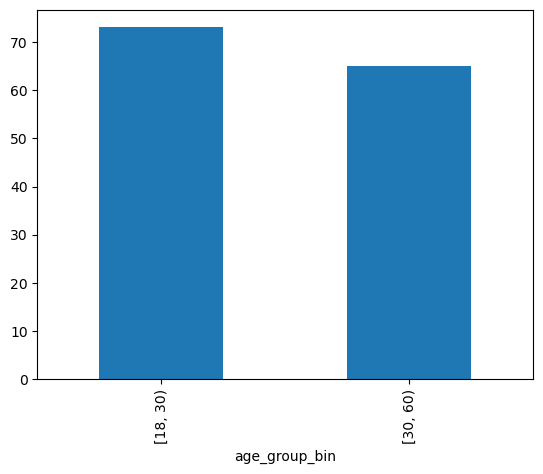

In [368]:
data[data['fraudulent']=='Yes'] \
.groupby('age_group_bin').size().plot(kind='bar')


#### 14. Visualize the monthly trend of the total amount that has been claimed by the customers. Ensure that on the “month” axis, the month is in a chronological order not alphabetical order. 

Text(0, 0.5, 'claim_amount')

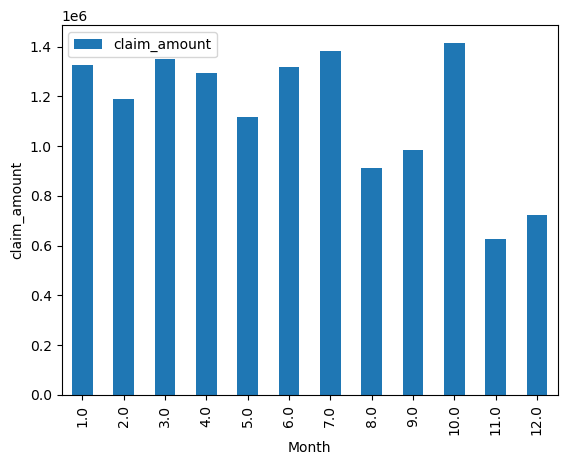

In [458]:
data['Month']=pd.to_datetime(data['claim_date']).dt.month
chart_month=pd.DataFrame(data.groupby('Month')['claim_amount'].sum())
chart_month=chart_month.reset_index()
chart_month.plot(kind='bar',x='Month',y='claim_amount')
plt.ylabel('claim_amount')

### 15. What is the average claim amount for gender and age categories and suitably represent the above using a facetted bar chart, one facet that represents fraudulent claims and the other for non-fraudulent claims.

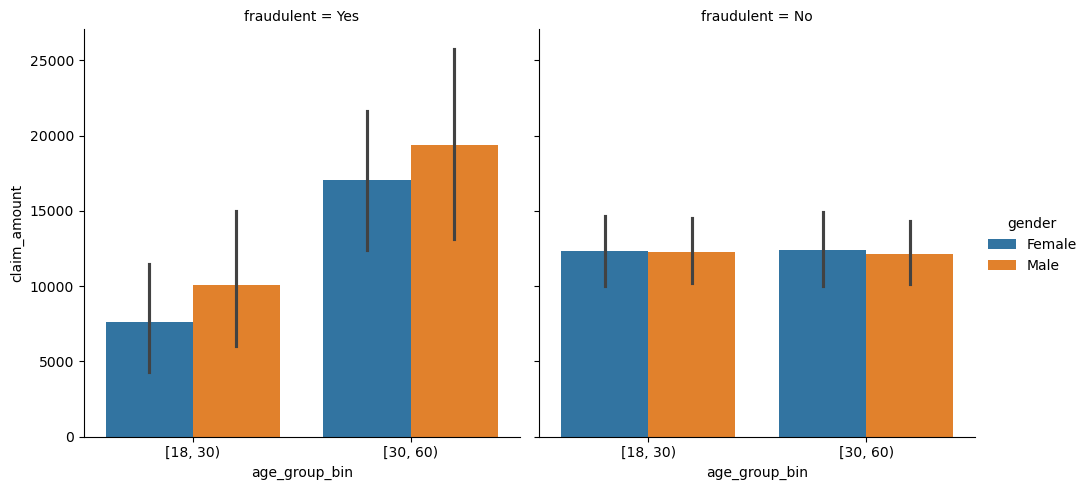

In [480]:
import seaborn as sns

sns.catplot(
    data=data,
    x='age_group_bin',
    y='claim_amount',
    hue='gender',
    col='fraudulent',
    kind='bar'
)


### 16. Is there any similarity in the amount claimed by males and females?

In [497]:
from scipy.stats import ttest_ind

male_claim = data[data['gender'] == 'Male']['claim_amount']
female_claim = data[data['gender'] == 'Female']['claim_amount']

t_stat, p_val = ttest_ind(male_claim, female_claim, nan_policy='omit')
t_stat, p_val


(np.float64(0.9627585967870055), np.float64(0.3358847899868228))

### 17. Is there any relationship between age category and segment?

In [498]:
data.head()

,index,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,...,DateOfBirth,State,Contact,Segment,police_report_0_1,police_alert,Age,Age_group,age_group_bin,Month
0,0,69348631.0,154557.0,Driver error,2018-04-10,Auto,No,Injury only,12475.266051,1.0,...,1978-05-23,DE,962-879-1238,Platinum,0,0,39.0,adult,"[30.0, 60.0)",4.0
1,1,40953049.0,263204.0,Other causes,2018-04-04,Auto,No,Material and injury,39192.000000,1.0,...,NaT,TX,173-892-6314,Silver,0,0,NaN,NaN,NaN,4.0
2,2,45780237.0,287476.0,Natural causes,2017-10-17,Auto,Unknown,Material only,1621.500000,2.0,...,1988-07-28,FL,364-598-1549,Silver,0,0,29.0,youth,"[18.0, 30.0)",10.0
3,3,89833962.0,441097.0,Other causes,2018-03-21,Auto,Yes,Material and injury,37040.000000,1.0,...,NaT,CA,187-348-8375,Gold,0,0,NaN,NaN,NaN,3.0
4,4,35782742.0,524545.0,Other driver error,2018-07-27,Auto,No,Injury only,35250.000000,3.0,...,1980-08-10,NC,798-862-5398,Gold,0,0,37.0,adult,"[30.0, 60.0)",7.0


In [499]:
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(data['age_group_bin'], data['Segment'])

chi2, p_val, dof, expected = chi2_contingency(cont_table)
chi2, p_val


(np.float64(2.21452796328834), np.float64(0.33046187507340297))

# 18. The current year has shown a significant rise in claim amounts as compared to 2016-17 fiscal average which was $10,000.

In [ ]:
19. Is there any difference between age groups and insurance claims?

In [503]:
from scipy.stats import f_oneway

groups = [
    grp['claim_amount'].dropna()
    for name, grp in data.groupby('age_group_bin')
]

f_stat, p_val = f_oneway(*groups)
f_stat, p_val


C:\Users\user\AppData\Local\Temp\ipykernel_13020\726677158.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, grp in data.groupby('age_group_bin')


(np.float64(3.433014887402159), np.float64(0.06436404227488014))

In [504]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(
    data['total_policy_claims'],
    data['claim_amount']
)

corr, p_val


(np.float64(-0.023900066023189663), np.float64(0.4296914202546214))